<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

## **2do Proyecto de Regresión Lineal**

**Autor:** Anais Aponte  
**Bootcamp:** 4Geeks Academy – Intro to Machine Learning  
**Proyecto:** Datos socio demográficos y de recursos de salud a nivel de condado de EE. UU. (2018-2019) 

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Instrucciones**

#### **Datos socio demográficos y de recursos de salud a nivel de condado de EE. UU. (2018-2019)**

El objetivo de este análisis es evaluar si existe una relación entre las características socio-demográficas de la población y sus indicadores de salud, con el fin de identificar posibles patrones que permitan explicar la prevalencia de enfermedades.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 1: Carga del conjunto de datos**

El dataset utilizado en este proyecto es **demographic_health_data.csv**.

Para facilitar la reproducibilidad y evitar dependencias externas, el archivo ha sido previamente descargado y almacenado dentro del repositorio en la siguiente ruta:

📁 `data/raw/demographic_health_data.csv`

De esta forma, el notebook puede ejecutarse directamente sin necesidad de acceder a enlaces externos.

A continuación se realizan primero las importaciones necesarias y, posteriormente, la carga del dataset para iniciar el análisis.

</div>

In [2]:
# IMPORTACIONES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Cargamos el fichero con los datos a analizar desde la carpeta raw del repositorio
# Usamos ruta relativa para asegurar portabilidad del notebook
df = pd.read_csv('../data/raw/demographic_health_data.csv')

# Visualizamos una muestra aleatoria de 10 registros para tener una primera impresión del dataset
# y evitar sesgarnos por un posible orden previo de las filas (ya que algunos datasets pueden estar ordenados (por fecha, id, etc.)
df.sample(10)

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
2732,48423,230221,31293,13.592591,31805,13.814986,31905,13.858423,29370,12.757307,...,13631,13.2,12.4,14.0,22842,3.4,3.2,3.6,5838,4
1864,36077,59749,5107,8.547423,7781,13.022812,9780,16.368475,5821,9.742422,...,4392,10.3,9.3,11.2,5154,3.1,2.9,3.4,1579,5
1625,30059,1866,210,11.254019,180,9.646302,149,7.984995,169,9.056806,...,132,13.3,12.0,14.6,200,3.9,3.6,4.3,59,6
1523,29085,9509,853,8.970449,944,9.927437,673,7.077506,775,8.150174,...,1086,17.0,15.7,18.4,1337,4.5,4.1,4.9,354,6
2782,49015,10014,1430,14.280008,1685,16.826443,1043,10.415418,1205,12.033154,...,499,11.9,11.0,12.8,848,3.2,3.0,3.5,229,6
98,4009,38072,5570,14.630174,5963,15.662429,5712,15.003152,5182,13.611053,...,2101,11.5,10.9,12.1,3201,3.3,3.1,3.5,921,5
1312,27001,15902,1331,8.370016,1562,9.822664,1207,7.590240,1316,8.275689,...,1097,13.9,12.6,15.1,1838,4.0,3.7,4.4,534,6
2888,51147,22950,2094,9.124183,3649,15.899782,5311,23.141612,2166,9.437908,...,1441,11.7,10.9,12.4,2237,3.1,3.0,3.3,604,6
2914,51520,16482,1737,10.538770,1878,11.394248,1984,12.037374,2036,12.352870,...,1401,13.6,12.4,14.7,1791,3.8,3.5,4.1,496,3
3001,54023,11626,1255,10.794770,1235,10.622742,1249,10.743162,1114,9.581971,...,1366,17.0,15.6,18.4,1589,4.0,3.6,4.3,370,6


In [4]:
# Listamos las columnas del dataset
df.columns
list(df.columns)

['fips',
 'TOT_POP',
 '0-9',
 '0-9 y/o % of total pop',
 '19-Oct',
 '10-19 y/o % of total pop',
 '20-29',
 '20-29 y/o % of total pop',
 '30-39',
 '30-39 y/o % of total pop',
 '40-49',
 '40-49 y/o % of total pop',
 '50-59',
 '50-59 y/o % of total pop',
 '60-69',
 '60-69 y/o % of total pop',
 '70-79',
 '70-79 y/o % of total pop',
 '80+',
 '80+ y/o % of total pop',
 'White-alone pop',
 '% White-alone',
 'Black-alone pop',
 '% Black-alone',
 'Native American/American Indian-alone pop',
 '% NA/AI-alone',
 'Asian-alone pop',
 '% Asian-alone',
 'Hawaiian/Pacific Islander-alone pop',
 '% Hawaiian/PI-alone',
 'Two or more races pop',
 '% Two or more races',
 'POP_ESTIMATE_2018',
 'N_POP_CHG_2018',
 'GQ_ESTIMATES_2018',
 'R_birth_2018',
 'R_death_2018',
 'R_NATURAL_INC_2018',
 'R_INTERNATIONAL_MIG_2018',
 'R_DOMESTIC_MIG_2018',
 'R_NET_MIG_2018',
 'Less than a high school diploma 2014-18',
 'High school diploma only 2014-18',
 "Some college or associate's degree 2014-18",
 "Bachelor's degree or 

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación**

El dataset contiene variables socio-demográficas y de salud a nivel de condado (cada observacion representa los datos de un condado), lo que permite analizar la relación entre las condiciones socioeconómicas de la población y distintos indicadores sanitarios.

En este caso, se establece como variable objetivo `obesity_prevalence`, al tratarse de una métrica continua que refleja el porcentaje de población con obesidad en cada región. Esta variable resulta especialmente adecuada para el análisis, ya que permite estudiar posibles desigualdades en salud relacionadas con factores como el nivel de ingresos, la educación o el acceso a recursos.

**Hipotesis: El objetivo del modelo será, por tanto, analizar en qué medida las variables socioeconómicas influyen en la prevalencia de obesidad, con especial interés en identificar si existe una relación entre menor nivel de recursos y mayores tasas de obesidad.**

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Variables relevantes para el análisis**

Dado el enfoque del estudio, centrado en analizar la relación entre factores socioeconómicos y la obesidad, se prestará especial atención a variables potencialmente relacionadas con:

- Indicadores de salud: `obesity_prevalence`, `diabetes_prevalence`, `COPD_prevalence`, entre otros.
- Factores socioeconómicos: variables asociadas a nivel de ingresos, pobreza, educación o acceso a recursos (por ejemplo, métricas relacionadas con renta, desempleo o nivel educativo, según disponibilidad en el dataset).
- Características demográficas: distribución por edad (`0–9`, `10–19`, etc.), población total (`TOT_POP`) y posibles indicadores de entorno (`Urban_rural_code`).

Estas variables se consideran candidatas iniciales para el análisis, y su relevancia será validada posteriormente mediante el análisis exploratorio de datos (EDA), donde se evaluarán sus relaciones con la variable objetivo `obesity_prevalence`.


</div>

-----

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2: Realiza un EDA completo**

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Orientacion del EDA**

El análisis exploratorio de datos (EDA) en este proyecto no se aborda de forma descriptiva, sino con un objetivo claro: validar la hipótesis planteada.

En concreto, se busca analizar si los factores socioeconómicos influyen en la prevalencia de obesidad (`obesity_prevalence`) en los distintos condados.

Para ello, el EDA se centrará en identificar relaciones relevantes entre la variable objetivo y aquellas variables que representan características demográficas y socioeconómicas de la población, priorizando el análisis de correlaciones y patrones significativos frente a una exploración indiscriminada de todas las variables disponibles.


</div>

In [5]:
# Revisamos dimensiones del dataset
df.shape

(3140, 108)

In [6]:
# Revisamos estructura, tipos de datos y valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), str(2)
memory usage: 2.6 MB


In [7]:
# Contamos valores nulos por columna y mostramos las más problemáticas
df.isnull().sum().sort_values(ascending=False).head(10)

fips                        0
TOT_POP                     0
0-9                         0
0-9 y/o % of total pop      0
19-Oct                      0
10-19 y/o % of total pop    0
20-29                       0
20-29 y/o % of total pop    0
30-39                       0
30-39 y/o % of total pop    0
dtype: int64

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación inicial del dataset**

El dataset presenta 3140 registros y 108 variables, lo que indica una alta dimensionalidad y la necesidad de seleccionar características relevantes durante el análisis.

A nivel estructural, se observa una predominancia de variables numéricas, adecuadas para un problema de regresión. 

No se detectan valores nulos, lo que permite avanzar sin necesidad de imputación en esta fase.

</div>

In [8]:
# Analizamos estadísticos básicos de la variable objetivo
df["Obesity_prevalence"].describe()

count    3140.000000
mean       35.019299
std         4.517088
min        15.200000
25%        32.400000
50%        35.400000
75%        37.900000
max        49.900000
Name: Obesity_prevalence, dtype: float64

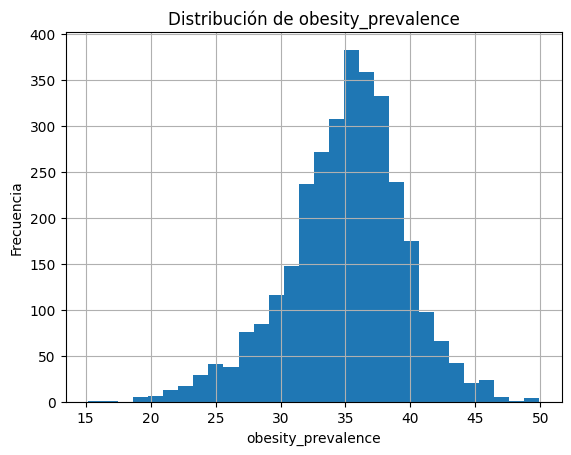

In [9]:
# Visualizamos la distribución de la variable objetivo
import matplotlib.pyplot as plt

df["Obesity_prevalence"].hist(bins=30)
plt.title("Distribución de obesity_prevalence")
plt.xlabel("obesity_prevalence")
plt.ylabel("Frecuencia")
plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación sobre la variable objetivo**

La variable `Obesity_prevalence` presenta una distribución aproximadamente simétrica y cercana a una distribución normal, con una media en torno a 35 y una dispersión moderada.

No se observan asimetrías pronunciadas ni valores extremos significativos, lo que indica que la variable es adecuada para ser modelada mediante técnicas de regresión sin necesidad de transformaciones adicionales.

</div>

In [10]:
# Seleccionamos solo variables numéricas para analizar correlaciones
df_num = df.select_dtypes(include=["int64", "float64"])

# Calculamos correlación con la variable objetivo
corr = df_num.corr()["Obesity_prevalence"].sort_values(ascending=False)

# Mostramos las variables más correlacionadas
corr.head(50)

Obesity_prevalence                                                         1.000000
Obesity_Upper 95% CI                                                       0.998239
Obesity_Lower 95% CI                                                       0.998117
anycondition_Lower 95% CI                                                  0.895747
anycondition_prevalence                                                    0.894438
anycondition_Upper 95% CI                                                  0.891291
diabetes_Lower 95% CI                                                      0.700502
diabetes_prevalence                                                        0.699402
diabetes_Upper 95% CI                                                      0.695159
COPD_Lower 95% CI                                                          0.613890
COPD_prevalence                                                            0.589318
Heart disease_Lower 95% CI                                                 0

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación sobre correlaciones y seleccion inicial de variables predictoras**

Se identifican altas correlaciones entre la variable objetivo (`Obesity_prevalence`) y variables relacionadas con la salud, como `diabetes_prevalence`, lo que sugiere una fuerte asociación entre la obesidad y la presencia de enfermedades crónicas.

Asimismo, se observan correlaciones moderadas con variables de carácter socioeconómico y demográfico, como el nivel educativo o la distribución racial, lo que refuerza la hipótesis de que factores sociales pueden influir en la prevalencia de obesidad.

Cabe destacar que variables agregadas como `anycondition_prevalence`, aunque presentan alta correlación, representan un indicador global del estado de salud. Dado que el dataset ya contiene variables específicas para cada condición (como diabetes, enfermedades cardiovasculares o respiratorias), se opta por excluir esta variable para evitar redundancia y posibles problemas de multicolinealidad, priorizando así una mayor interpretabilidad del modelo.

</div>

In [11]:
# Eliminamos columnas no relevantes: CI, agregadas e identificadores
cols_to_drop = [col for col in df.columns if "CI" in col] + ["anycondition_prevalence", "fips"]

df_clean = df.drop(columns=cols_to_drop)
df_clean.head(10)

,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,...,Obesity_number,Heart disease_prevalence,Heart disease_number,COPD_prevalence,COPD_number,diabetes_prevalence,diabetes_number,CKD_prevalence,CKD_number,Urban_rural_code
0,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,...,15193,7.9,3345,8.6,3644,12.9,5462,3.1,1326,3
1,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,...,50761,7.8,13414,8.6,14692,12.0,20520,3.2,5479,4
2,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,...,8013,11.0,2159,12.1,2373,19.7,3870,4.5,887,6
3,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,3038,...,6894,8.6,1533,10.0,1789,14.1,2511,3.3,595,2
4,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,7474,...,15112,9.2,4101,10.5,4661,13.5,6017,3.4,1507,2
5,10138,1198,11.816926,1130,11.146183,1395,13.760110,1446,14.263168,1274,...,3664,10.0,804,10.9,873,20.6,1651,4.5,360,6
6,19680,2351,11.946138,2461,12.505081,2286,11.615854,2337,11.875000,2318,...,6304,10.4,1588,11.4,1741,18.6,2841,4.3,662,6
7,114277,13141,11.499252,14637,12.808352,15463,13.531157,13865,12.132800,13727,...,36639,9.1,8146,10.2,9158,14.7,13182,3.6,3204,4
8,33615,3869,11.509743,3812,11.340176,4380,13.029897,3734,11.108136,4078,...,10410,9.8,2618,10.8,2870,17.5,4664,4.0,1068,5
9,26032,2554,9.811002,2981,11.451291,2852,10.955747,2504,9.618931,3204,...,8227,10.8,2282,12.1,2540,15.9,3353,3.9,814,6


In [12]:
# Verificamos nuevas dimensiones tras limpieza
df_clean.shape

(3140, 92)

In [13]:
# Separamos variables predictoras y objetivo
X = df_clean.drop(columns=["Obesity_prevalence"])
y = df_clean["Obesity_prevalence"]

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3: Construye un modelo de regresión**

</div>

In [14]:
# Observamos cuales son las variables categoricas que nos quedan 
X_cat = X.select_dtypes(include=["str"])
X_cat

,COUNTY_NAME,STATE_NAME
0,Autauga,Alabama
1,Baldwin,Alabama
2,Barbour,Alabama
3,Bibb,Alabama
4,Blount,Alabama
...,...,...
3135,Sweetwater,Wyoming
3136,Teton,Wyoming
3137,Uinta,Wyoming
3138,Washakie,Wyoming


<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación sobre variables categóricas**

Las variables categóricas `COUNTY_NAME` y `STATE_NAME` se excluyen en la construcción del modelo base, ya que representan identificadores geográficos y no aportan información numérica directa al modelo.

Además, los modelos de regresión lineal requieren variables numéricas, por lo que estas variables necesitarían ser transformadas mediante técnicas de codificación (como one-hot encoding) para poder ser utilizadas.

Dado que el objetivo en esta fase es construir un modelo base sencillo e interpretable, se opta por trabajar únicamente con variables numéricas, dejando la incorporación de variables categóricas para etapas posteriores de mejora del modelo.

</div>

In [15]:
# Seleccionamos únicamente variables numéricas para el modelo base
X_num = X.select_dtypes(include=["int64", "float64"])

In [16]:
# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)
y_train

1292    38.6
2302    33.2
761     33.7
2194    36.5
1241    37.5
        ... 
3092    32.6
1095    37.2
1130    39.0
1294    36.3
860     36.5
Name: Obesity_prevalence, Length: 2512, dtype: float64

In [17]:
# Entrenamos modelo base de regresión lineal
model_base = LinearRegression()
model_base.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
# Generamos predicciones sobre el conjunto de test
y_pred = model_base.predict(X_test)

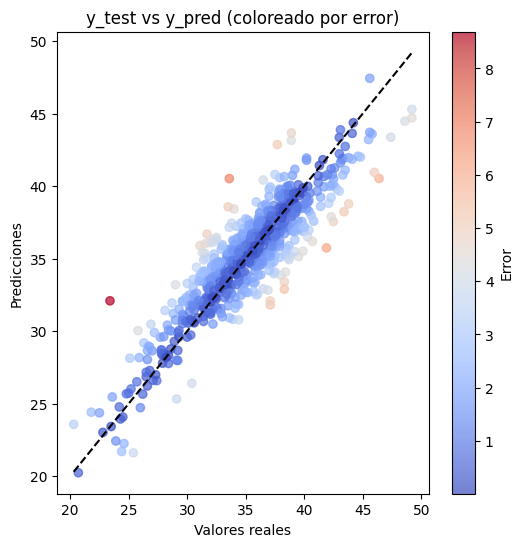

In [19]:
# Calculamos el error absoluto
errors = abs(y_test - y_pred)

plt.figure(figsize=(6,6))

scatter = plt.scatter(
    y_test,
    y_pred,
    c=errors,
    cmap="coolwarm",
    alpha=0.7
)

# Línea ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--'
)

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("y_test vs y_pred (coloreado por error)")

plt.colorbar(scatter, label="Error")
plt.show()

In [20]:
# Evaluamos el rendimiento del modelo

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Guardamos métricas en un diccionario para facilitar comparaciones posteriores
metrics_base = {
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
}

# Convertimos las métricas en DataFrame para visualización
metrics_df = pd.DataFrame({
    "Modelo base": metrics_base
})

# Formateamos los valores para mejorar la legibilidad
metrics_df = metrics_df.map(lambda x: f"{x:.4f}")
metrics_df

,Modelo base
MAE,1.5687
MSE,4.0604
RMSE,2.0150
R2,0.8034



<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación sobre el rendimiento del modelo base**

El modelo base presenta un buen desempeño, con un R² cercano a 0.80, lo que indica una alta capacidad para explicar la variabilidad de la prevalencia de obesidad entre los distintos condados.

Asimismo, los valores de MAE y RMSE muestran que el modelo comete errores relativamente bajos en términos absolutos, situándose en torno a 1.5–2 puntos porcentuales.

A pesar de este buen rendimiento, se explorarán técnicas de regularización como Lasso con el objetivo de simplificar el modelo, reducir la posible redundancia entre variables y mejorar su capacidad de generalización.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 3.1: Construye un modelo Lasso**

</div>

In [21]:
# Entrenamos modelo Lasso con parámetros por defecto
lasso_model = Lasso(random_state=42)
lasso_model.fit(X_train, y_train)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.221e+03, tolerance: 5.108e+00
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [22]:
# Generamos predicciones con el modelo Lasso
y_pred_lasso = lasso_model.predict(X_test)

In [23]:
# Calculamos métricas del modelo Lasso
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

In [24]:
# Guardamos métricas del modelo Lasso
metrics_lasso = {
    "MAE": mae_lasso,
    "MSE": mse_lasso,
    "RMSE": rmse_lasso,
    "R2": r2_lasso
}

# Creamos DataFrame comparativo
comparison_df = pd.DataFrame({
    "Modelo base": metrics_base,
    "Lasso": metrics_lasso
})

# Formateamos valores
comparison_df = comparison_df.map(lambda x: f"{x:.4f}")
comparison_df

,Modelo base,Lasso
MAE,1.5687,1.9189
MSE,4.0604,5.8496
RMSE,2.0150,2.4186
R2,0.8034,0.7167


<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación sobre convergencia en el modelo Lasso**

Al entrenar el modelo Lasso con los datos originales, se observa un warning indicando que el modelo no ha convergido correctamente.

Este comportamiento se debe a que Lasso es un algoritmo sensible a la escala de las variables. Cuando las variables presentan magnitudes muy diferentes, el proceso de optimización puede volverse inestable o no alcanzar una solución óptima dentro del número de iteraciones establecido.

Por ello, resulta necesario aplicar un proceso de escalado (como StandardScaler) antes de entrenar el modelo, con el objetivo de homogeneizar las variables y facilitar la convergencia del algoritmo.

</div>

In [25]:
# Escalamos las variables antes de usar Lasso
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
# Entrenamos Lasso con datos escalados y más iteraciones
lasso_model = Lasso(random_state=42, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [27]:
# Predicciones
y_pred_lasso = lasso_model.predict(X_test_scaled)

In [28]:
# Calculamos métricas para Lasso con datos escalados
mae_lasso_scaled = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso_scaled = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso_scaled = np.sqrt(mse_lasso_scaled)
r2_lasso_scaled = r2_score(y_test, y_pred_lasso)

In [29]:
# Guardamos métricas del modelo Lasso escalado
metrics_lasso_scaled = {
    "MAE": mae_lasso_scaled,
    "MSE": mse_lasso_scaled,
    "RMSE": rmse_lasso_scaled,
    "R2": r2_lasso_scaled
}

In [30]:
# Añadimos columna al DataFrame comparativo
comparison_df["Lasso_scaled"] = metrics_lasso_scaled

In [31]:
# Reconstruimos la tabla comparativa desde métricas numéricas
comparison_df = pd.DataFrame({
    "Modelo base": metrics_base,
    "Lasso": metrics_lasso,
    "Lasso_scaled": metrics_lasso_scaled
})

# Formateamos valores para visualización
comparison_df = comparison_df.map(lambda x: f"{x:.4f}")

comparison_df

,Modelo base,Lasso,Lasso_scaled
MAE,1.5687,1.9189,2.4115
MSE,4.0604,5.8496,9.7004
RMSE,2.0150,2.4186,3.1145
R2,0.8034,0.7167,0.5302


<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación sobre Lasso con parámetros por defecto**

Al aplicar Lasso con sus parámetros por defecto, el rendimiento disminuye respecto al modelo base. Esto indica que el nivel de regularización inicial (`alpha=1`) puede ser demasiado alto para este dataset, reduciendo en exceso la contribución de variables que sí aportan información predictiva.

Por este motivo, es necesario analizar cómo evoluciona el R² al modificar el valor de `alpha`.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 3.2: Analisa como evoluciona R2 segun alpha en el modelo Lasso**

</div>

In [32]:
# Probamos valores de alpha desde 0 hasta 20 y guardamos el R2
alphas = np.linspace(0.001, 20, 50)
r2_scores = []

for alpha in alphas:
    # Creamos modelo Lasso con alpha variable
    model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    
    # Entrenamos con datos escalados
    model.fit(X_train_scaled, y_train)
    
    # Predecimos
    y_pred = model.predict(X_test_scaled)
    
    # Guardamos R2
    r2_scores.append(r2_score(y_test, y_pred))

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.173e+02, tolerance: 5.108e+00
  model = cd_fast.enet_coordinate_descent(


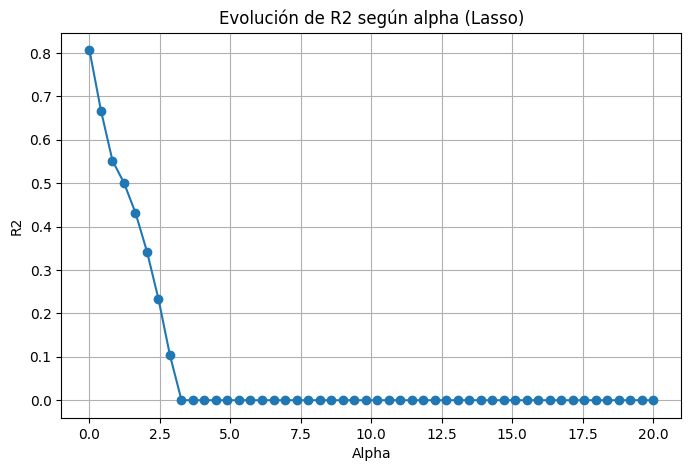

In [33]:
# Visualizamos cómo cambia el R2 según alpha
plt.figure(figsize=(8,5))
plt.plot(alphas, r2_scores, marker='o')

plt.xlabel("Alpha")
plt.ylabel("R2")
plt.title("Evolución de R2 según alpha (Lasso)")

plt.grid()
plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Observación sobre optimización de Lasso**

Tras optimizar el parámetro alpha en el rango [0, 20], se observa que el mejor rendimiento del modelo se obtiene con un valor muy cercano a 0 (alpha ≈ 0.001).

Esto implica que la regularización aplicada por Lasso es prácticamente nula, y que el modelo se comporta de forma muy similar a la regresión lineal base.

Aunque se observa una ligera mejora en las métricas (especialmente en R²), esta es marginal, lo que confirma que el modelo base ya capturaba adecuadamente las relaciones entre variables y no requería una penalización significativa.

En consecuencia, Lasso no aporta un beneficio sustancial en este caso, más allá de una leve estabilización del modelo.

</div>

-----

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 4: Optimiza el modelo de regresion anterior**

</div>

In [34]:
# Seleccionamos el alpha que obtuvo el mayor R2
best_alpha = alphas[np.argmax(r2_scores)]

best_alpha

np.float64(0.001)

In [35]:
# Entrenamos Lasso con el mejor alpha encontrado
lasso_best = Lasso(alpha=best_alpha, random_state=42, max_iter=10000)

# Entrenamos el modelo con datos escalados
lasso_best.fit(X_train_scaled, y_train)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.173e+02, tolerance: 5.108e+00
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",np.float64(0.001)
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [36]:
# Generamos predicciones con el modelo Lasso optimizado
y_pred_best = lasso_best.predict(X_test_scaled)

In [37]:
# Calculamos métricas del mejor modelo Lasso encontrado
mae_lasso_best = mean_absolute_error(y_test, y_pred_best)
mse_lasso_best = mean_squared_error(y_test, y_pred_best)
rmse_lasso_best = np.sqrt(mse_lasso_best)
r2_lasso_best = r2_score(y_test, y_pred_best)

In [38]:
# Guardamos métricas del modelo Lasso optimizado
metrics_lasso_best = {
    "MAE": mae_lasso_best,
    "MSE": mse_lasso_best,
    "RMSE": rmse_lasso_best,
    "R2": r2_lasso_best
}

In [39]:
# Reconstruimos tabla comparativa completa
comparison_df = pd.DataFrame({
    "Modelo base": metrics_base,
    "Lasso": metrics_lasso,
    "Lasso_scaled": metrics_lasso_scaled,
    "Lasso_best": metrics_lasso_best
})

# Formateamos
comparison_df = comparison_df.map(lambda x: f"{x:.4f}")

comparison_df

,Modelo base,Lasso,Lasso_scaled,Lasso_best
MAE,1.5687,1.9189,2.4115,1.5609
MSE,4.0604,5.8496,9.7004,3.9995
RMSE,2.0150,2.4186,3.1145,1.9999
R2,0.8034,0.7167,0.5302,0.8063


<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### **Optimización del modelo Lasso**

Tras entrenar el modelo Lasso inicial, se observaron problemas de convergencia y una degradación en el rendimiento respecto al modelo base.

Para mejorar su comportamiento, se aplicaron las siguientes técnicas:

- Escalado de variables mediante StandardScaler, necesario para modelos regularizados.
- Incremento del número máximo de iteraciones (max_iter).
- Búsqueda del mejor valor del hiperparámetro alpha en el rango [0, 20].

Como resultado, se identificó un valor óptimo de alpha cercano a 0 (≈ 0.001), con el que el modelo mejora ligeramente sus métricas respecto a la regresión lineal base.

Esto confirma que, aunque Lasso puede estabilizar el modelo, en este caso la regularización no aporta mejoras significativas, ya que el modelo base ya captura adecuadamente la relación entre variables.

</div>

In [40]:
# Obtenemos coeficientes del modelo Lasso óptimo (con signo)
coef_lasso = pd.Series(lasso_best.coef_, index=X_train.columns)

# Variables más influyentes (sin importar signo)
coef_lasso.abs().sort_values(ascending=False).head(10)

Obesity_number          15.845574
diabetes_number          7.910210
Heart disease_number     6.949442
40-49                    4.451349
19-Oct                   4.314822
diabetes_prevalence      3.989414
60-69                    3.623061
30-39                    3.466279
CKD_number               3.238572
CKD_prevalence           3.217182
dtype: float64

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### **Conclusion sobre la hipotesis**

**Hipotesis: “¿La gente con menos recursos es más obesa?”**

El análisis muestra que las variables con mayor capacidad explicativa sobre la obesidad están principalmente relacionadas con el estado de salud (como la diabetes o enfermedades cardiovasculares), lo que refleja la fuerte interrelación entre distintas condiciones crónicas.

Sin embargo, aunque el objetivo inicial era analizar el impacto de factores socioeconómicos, estos no aparecen entre las variables más influyentes en el modelo, lo que sugiere que su efecto es más débil o está parcialmente capturado por otras variables más directamente relacionadas con la salud.

Esto indica que, si bien los factores socioeconómicos pueden influir en la obesidad, su impacto no es tan directo ni tan fuerte como el de las condiciones de salud en este dataset concreto.

Por tanto, no se puede confirmar de forma concluyente que la población con menores recursos presente mayores niveles de obesidad a partir de este modelo, siendo necesario un análisis más específico centrado en variables socioeconómicas para validar esta hipótesis.

En conjunto, este análisis permite entender que, aunque existen factores socioeconómicos asociados a la obesidad, las variables de salud tienen un peso explicativo mayor en este dataset, lo que limita la capacidad de validar completamente la hipótesis inicial.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 5: Guardado del modelo**

</div>

In [41]:
# Guardamos el modelo Lasso optimizado en disco
joblib.dump(lasso_best, "../models/lasso_best_obesity_model.sav")

# Guardamos también el scaler usado
joblib.dump(scaler, "../models/lasso_scaler_obesity.sav")

['../models/lasso_scaler_obesity.sav']